# 5 - Estações — Distinção entre pontos amostrais e clustering

## Objetivo

Comparar as **8 estações** do sistema lagunar de Jacarepaguá para entender se elas se comportam como um sistema homogêneo ou se subgrupos distintos podem ser identificados. Revisita o k-means do PIBIC anterior (2023/2024) sobre o dataset estendido 2012–2025.

## Pergunta que responde

> As estações são estatisticamente distintas? Vale tratar `Codigo Local` como feature de uma única GAIN, ou clusters justificam uma GAIN por cluster?

## Posição na Etapa 1 — EDA

Notebook **5 de 6**. Responde à quinta das 5 perguntas-meta:

1. Quais variáveis têm boa cobertura e quais são críticas? → `01_descritivo.ipynb`
2. Quais variáveis são simétricas vs assimétricas? → `02_distribuicoes.ipynb`
3. Quais pares são correlacionados? → `03_correlacoes.ipynb`
4. Há padrão temporal? → `04_temporal.ipynb`
5. **As estações são distintas?** ← *este notebook*
6. A censura é estruturada? → `06_lds.ipynb`

## Hipótese

O sistema lagunar de Jacarepaguá tem **gradiente espacial conhecido**:

- **Marapendi (MR361, MR363, MR369)** e **Tijuca/Joatinga (TJ303, TJ306)** estão mais próximas do mar, com influência marinha (alta Condutividade/salinidade).
- **Camorim (CM320)** e **Jacarepaguá (JC341, JC342)** são mais internas, recebem aporte direto de efluentes urbanos (DBO, Coliformes, Fósforo altos).
- Esperamos pelo menos **2 clusters claros** (marinho vs continental), possivelmente 3 (com intermediário).
- O PIBIC 2023/2024 (Dannylo) usou k-means com K = 3 sobre dados 2012–2019. Aqui estendemos para 2012–2025 e revisitamos.

## Resumo executivo

- **As estações são fortemente distintas:** 8 das 13 variáveis rejeitam homogeneidade entre estações (Kruskal-Wallis p < 0,01). Os discriminadores mais fortes são **Condutividade (H = 322)**, **Turbidez (H = 278)**, **Fósforo Total (H = 242)** e **DBO (H = 206)** — exatamente os indicadores que separam águas marinhas de águas urbanizadas.
- **PCA captura 70% da variância em 2 dimensões** (PC1 = 50%, PC2 = 20%). PC1 separa **eutrofizadas** (CM320, JC342: PC1 ≈ +2,5 a +2,9) de **marinhas/limpas** (MR369, TJ303: PC1 ≈ −3,8 a −4,1). PC2 (eixo OD/pH × Coliformes) separa CM320/TJ306 (mais contaminadas) das demais.
- **Dendrograma (Ward) e silhueta indicam K = 2 como número natural de clusters** (silhueta = 0,335 — único valor positivo decente): {MR369, TJ303} vs todas as demais. K = 3 (silhueta = 0,254) adiciona um cluster intermediário {CM320, TJ306}, com ganho marginal.
- **JC341 e MR363 são outliers ruidosos** (n = 10 e 8 respectivamente). Suas posições no PCA são instáveis e suas atribuições de cluster mudam entre K. Tratá-las com cautela na modelagem.
- **Decisão arquitetural confirmada — GAIN única com `Codigo Local` como feature one-hot.** Embora as estações sejam distintas, **fragmentar o dataset em 2 ou 3 GANs separadas seria contraproducente:** o cluster minoritário (MR369+TJ303) teria ~228 amostras, abaixo do mínimo viável para treinar uma GAN robusta. Uma única GAIN aprende todas as estações simultaneamente e o feature condicional `Codigo Local` permite ao gerador especializar a distribuição implicitamente.

## Setup

Imports + `sklearn` (StandardScaler, PCA, KMeans, silhueta), `scipy.cluster.hierarchy` (linkage, dendrograma) e `scipy.stats` (kruskal, mannwhitneyu).

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
OUTPUT_BASE = Path("../../Data/Figures/01_EDA")
FIG_DIR     = OUTPUT_BASE / "figuras"
TAB_DIR     = OUTPUT_BASE / "tabelas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]

STATIONS = ["JC341", "JC342", "CM320", "MR361", "MR363", "MR369", "TJ303", "TJ306"]

MIN_N_KW  = 5      # mínimo por estação para entrar no Kruskal-Wallis
P_THRESH  = 0.05   # significância
RANDOM_STATE = 42  # reprodutibilidade do K-means

## Carregamento

Lê o dataset e mantém `Codigo Local` + as 13 variáveis numéricas.

In [2]:
df = pd.read_excel(DATA_PATH)
df_num = df[["Codigo Local", *VARS]].copy()
print(f"Shape: {df_num.shape}")
print(f"\nAmostras por estação:\n{df_num.groupby('Codigo Local').size()}")

Shape: (657, 14)

Amostras por estação:
Codigo Local
CM320    114
JC341     10
JC342    114
MR361    115
MR363      8
MR369    115
TJ303    113
TJ306     68
dtype: int64


## 1. Estatística descritiva por estação

Tabela cruzada com **mediana** de cada variável por estação (mediana é mais robusta que média na presença de outliers — ver `02_distribuicoes.ipynb`). Em seguida, grid 4×4 de boxplots permitindo a leitura visual dos contrastes.

In [3]:
tab_mediana = df_num.groupby("Codigo Local")[VARS].median()
tab_mediana.T.round(2)

Codigo Local,CM320,JC341,JC342,MR361,MR363,MR369,TJ303,TJ306
DBO,20.00,16.00,16.24,13.60,14.60,6.70,7.20,16.00
OD,3.70,8.20,4.00,4.81,6.25,5.30,4.60,3.56
Nitrato,0.03,NaN,0.02,0.02,NaN,0.04,0.04,0.02
Nitrogênio Amoniacal Total,5.22,4.84,4.82,4.85,4.70,1.40,2.48,4.98
Fósforo Total,1.17,1.55,1.33,1.22,0.72,0.62,0.52,0.90
Condutividade,8019.00,7930.00,5026.00,17555.00,35340.00,30700.00,33675.00,15960.00
pH,7.80,8.88,7.70,7.90,8.20,7.70,7.72,7.80
Turbidez,56.10,65.00,52.00,15.00,7.85,7.06,9.48,26.50
Temperatura da Água,24.75,24.50,25.00,25.00,25.50,24.10,23.00,25.00
Sólidos Suspensos Totais,48.50,46.00,39.50,45.00,NaN,57.00,54.00,50.00


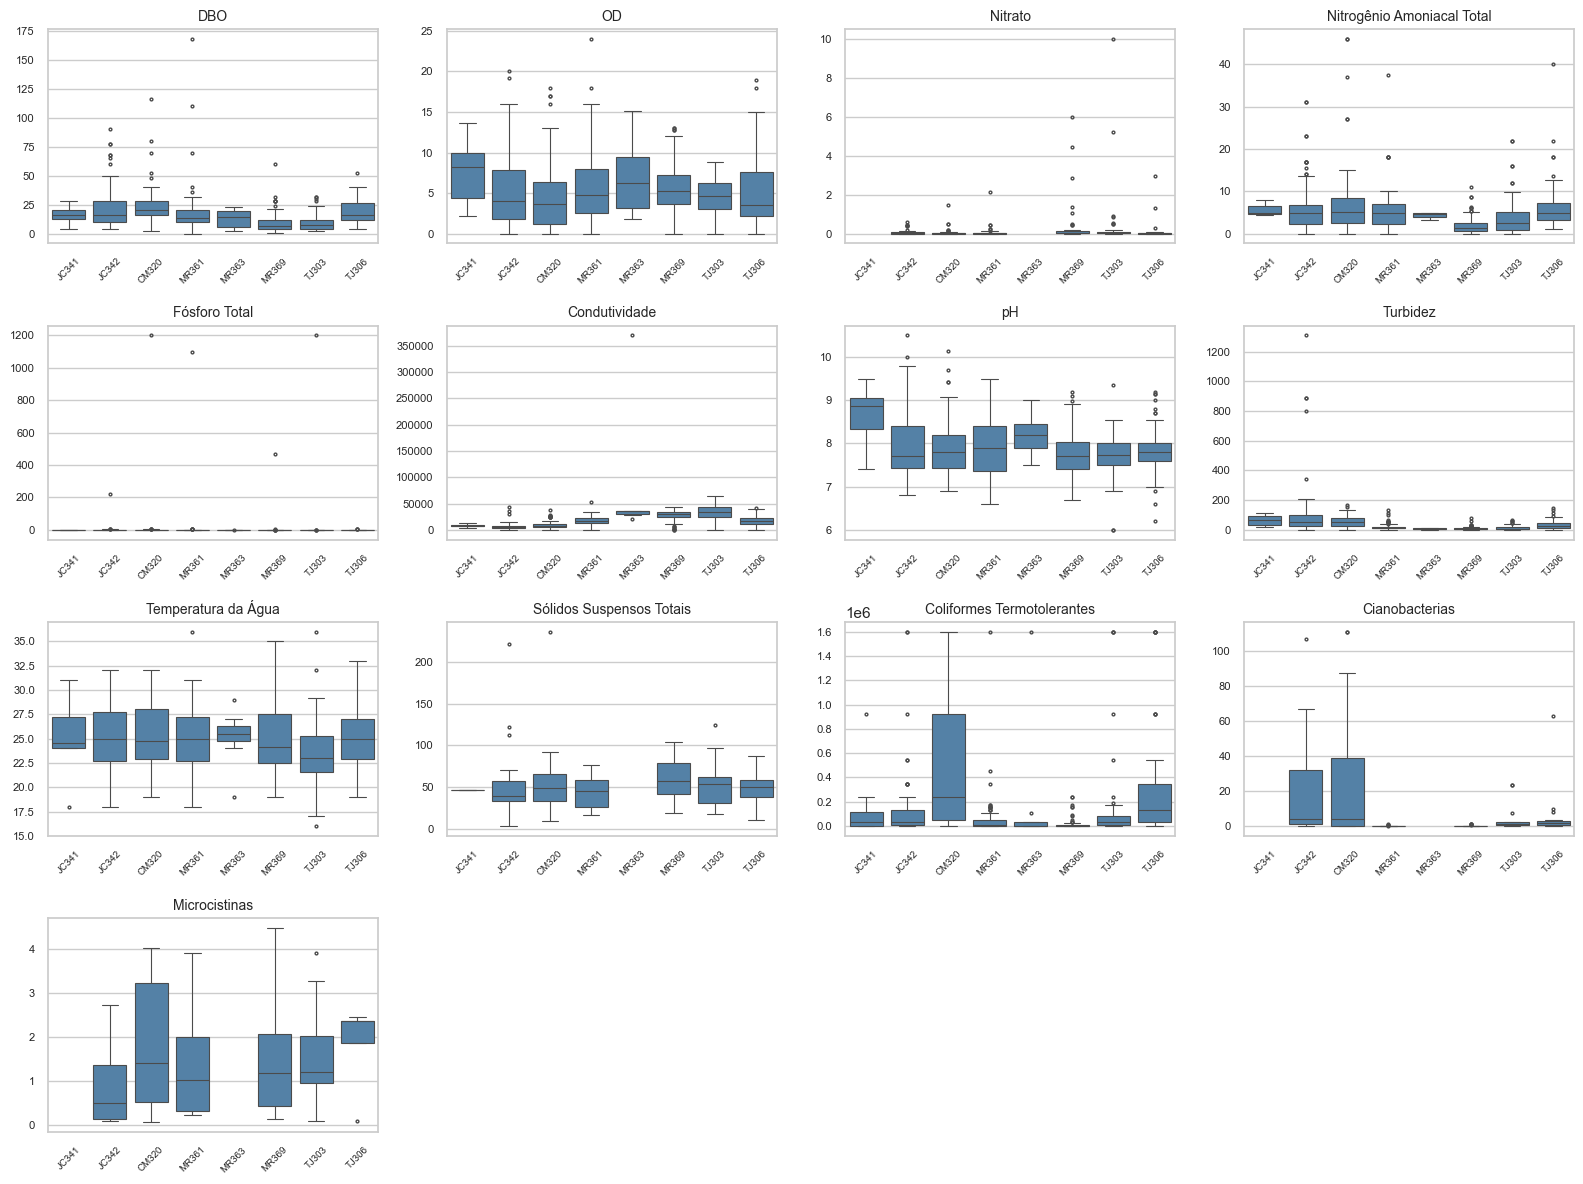

In [4]:
ncols = 4
nrows = (len(VARS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, v in zip(axes, VARS):
    sns.boxplot(
        data=df_num, x="Codigo Local", y=v, order=STATIONS, ax=ax,
        color="steelblue", fliersize=2, linewidth=0.8,
    )
    ax.set_title(v, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.tick_params(axis="y", labelsize=8)

for ax in axes[len(VARS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "est_boxplots_por_estacao.png", dpi=150)
plt.show()

**Como interpretar:**

- Estações com box em níveis muito diferentes da maioria = candidatas a cluster próprio.
- Estações com box parecido = redundantes na descrição do sistema.
- Variáveis com box semelhante em todas as estações = sinal pobre para discriminar estações (devem ter Kruskal-Wallis fraco).

**Achados específicos:**

- **TJ303 destaca-se em todas as variáveis-chave** — mediana de Condutividade ≈ 33.700 (vs ~8.000–16.000 nas demais), DBO mais baixa (7,2), Turbidez mais baixa (9,5), Nitrogênio Amoniacal mais baixo (2,5). **Assinatura marinha clara.**
- **CM320 e JC342 são as mais eutrofizadas:** mediana de Coliformes Termotolerantes de 240 mil (CM320) e ~130 mil; DBO 20 e 16; Fósforo Total 1,17 e 1,55. Recebem o aporte urbano mais pesado.
- **MR369 ocupa posição intermediária** mas com Condutividade alta (~14.000) — mais marinha que as JC/CM mas menos que TJ303.
- **Temperatura da Água e pH variam pouco entre estações** (medianas ~24–25 °C e ~7,7–7,8) — variáveis de pouca utilidade para discriminar estações (esperado: refletem clima regional, não local).
- **JC341 e MR363** mostram caixas estreitas com pouca variabilidade — mas isso reflete o n pequeno (10 e 8), não estabilidade real.

## 2. Kruskal-Wallis — as estações são distintas?

Para cada variável: teste de Kruskal-Wallis comparando as distribuições entre as 8 estações. Vantagens:

- **Não-paramétrico** — não exige normalidade (já sabemos que 10/13 variáveis são assimétricas — ver `02_distribuicoes.ipynb`).
- **Robusto a tamanhos desiguais** — JC341 (10) vs MR369 (115) funciona.
- `p < 0,05` rejeita a hipótese de que as 8 estações vêm da mesma distribuição.

Em seguida, **heatmap par-a-par** com Mann-Whitney + correção de Bonferroni mostra **quais pares** de estações são realmente diferentes (KW só diz que pelo menos uma é diferente).

In [5]:
def kw_entre_estacoes(serie: pd.Series, estacoes: pd.Series, min_n: int = MIN_N_KW):
    grupos = [serie[estacoes == st].dropna().values for st in STATIONS]
    grupos = [g for g in grupos if len(g) >= min_n]
    if len(grupos) < 3:
        return np.nan, np.nan, len(grupos)
    h, p = stats.kruskal(*grupos)
    return float(h), float(p), len(grupos)


rows = []
for v in VARS:
    h, p, n_grupos = kw_entre_estacoes(df_num[v], df_num["Codigo Local"])
    n_por_estacao = df_num.groupby("Codigo Local")[v].count().to_dict()
    rows.append({
        "variavel":             v,
        "H":                    h,
        "pvalue":               p,
        "n_estacoes_validas":   n_grupos,
        "distintas":            "sim" if (not np.isnan(p) and p < P_THRESH) else "nao",
        "n_min":                min(n_por_estacao.values()),
        "n_max":                max(n_por_estacao.values()),
    })

tab_kw = pd.DataFrame(rows).set_index("variavel").sort_values("H", ascending=False)
tab_kw

,H,pvalue,n_estacoes_validas,distintas,n_min,n_max
variavel,,,,,,
Condutividade,321.746477,1.364686e-65,8,sim,8,112
Turbidez,277.940754,3.086653e-56,8,sim,8,110
Fósforo Total,242.132763,1.307698e-48,8,sim,8,108
DBO,205.823811,6.700234e-41,8,sim,8,112
Coliformes Termotolerantes,161.099333,1.882896e-31,8,sim,8,84
Nitrogênio Amoniacal Total,82.154994,2.970295e-16,6,sim,3,91
Cianobacterias,53.495285,2.661084e-10,6,sim,0,25
OD,22.573780,2.021594e-03,8,sim,8,113
pH,21.576703,3.004084e-03,8,sim,8,111


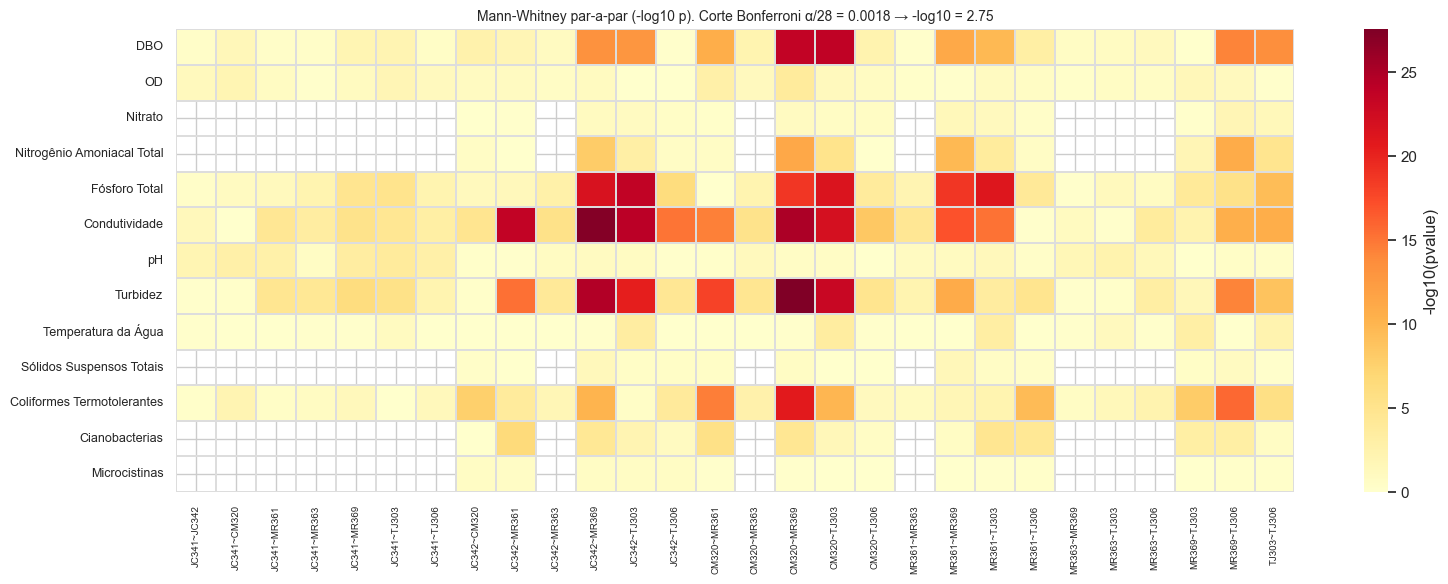

Condutividade                 22
Turbidez                      20
Fósforo Total                 14
Coliformes Termotolerantes    11
DBO                           10
Nitrogênio Amoniacal Total     8
Cianobacterias                 8
Temperatura da Água            4
pH                             4
OD                             2
Nitrato                        0
Sólidos Suspensos Totais       0
Microcistinas                  0
Name: n_pares_distintos, dtype: int64

In [6]:
# Mann-Whitney par-a-par com Bonferroni: para cada variavel, conta quantas estacoes
# diferem entre si. Visualizacao: heatmap variavel x par_de_estacoes.
pares = list(combinations(STATIONS, 2))
n_pares = len(pares)
alpha_corr = P_THRESH / n_pares  # Bonferroni

mat_p = pd.DataFrame(np.nan, index=VARS, columns=[f"{a}~{b}" for a, b in pares])
for v in VARS:
    for a, b in pares:
        xa = df_num[df_num["Codigo Local"] == a][v].dropna()
        xb = df_num[df_num["Codigo Local"] == b][v].dropna()
        if len(xa) < MIN_N_KW or len(xb) < MIN_N_KW:
            continue
        r = stats.mannwhitneyu(xa, xb, alternative="two-sided")
        mat_p.loc[v, f"{a}~{b}"] = float(r.pvalue)

# Plota -log10(p) para enxergar diferencas pequenas; marca corte de Bonferroni
mat_log = -np.log10(mat_p.clip(lower=1e-300))
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    mat_log, ax=ax, cmap="YlOrRd", cbar_kws={"label": "-log10(pvalue)"},
    linewidths=0.3, linecolor="#dddddd",
)
ax.set_title(
    f"Mann-Whitney par-a-par (-log10 p). Corte Bonferroni α/{n_pares} = {alpha_corr:.4f} "
    f"→ -log10 = {-np.log10(alpha_corr):.2f}",
    fontsize=10,
)
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / "est_kruskal_heatmap.png", dpi=150)
plt.show()

# Quantos pares passam Bonferroni para cada variavel
(mat_p < alpha_corr).sum(axis=1).sort_values(ascending=False).rename("n_pares_distintos")

**Como interpretar:**

- **Linha clara no heatmap** = variável discrimina pares de estações com força (cores intensas = p extremamente pequeno).
- **Linha pálida** = variável não separa estações bem.
- O corte de Bonferroni (α/28) é conservador: só os pares acima dele são considerados realmente distintos.

**Achados específicos:**

- **8 de 13 variáveis** rejeitam homogeneidade entre estações (Kruskal-Wallis p < 0,01). Em ordem decrescente de força discriminativa: **Condutividade (H = 322), Turbidez (H = 278), Fósforo Total (H = 242), DBO (H = 206), Coliformes (H = 161), Nitrogênio Amoniacal (H = 82), Cianobactérias (H = 54), pH (H = 22)**.
- **Variáveis fracas para separar estações:** Microcistinas (H = 4, p = 0,60), Sólidos Suspensos Totais (H = 7, p = 0,25), Nitrato (H = 10, p = 0,07). Refletem fenômenos regionais ou são raras demais.
- **Condutividade isola praticamente todos os pares** (>25 pares com p < α_Bonf) — é a variável de assinatura espacial mais clara. Coerente com gradiente marinho→continental.
- **Mesmo `Temperatura da Água` (que esperaríamos ser uniforme) discrimina algumas estações** (H = 21, p = 0,005) — provavelmente devido a microclimas locais (sombreamento, profundidade).

## 3. PCA das estações

Construímos um **perfil mediano** de cada estação (mediana de cada variável → matriz 8 × 13), padronizamos via z-score e projetamos em 2D via PCA.

Mediana é preferível à média (mais robusta a outliers); padronização é obrigatória porque as escalas das variáveis variam em ordens de magnitude (pH ≈ 7 vs Coliformes ≈ 100.000). NaN nas medianas (variáveis raras em estações pequenas) são preenchidos com a mediana global.

In [7]:
# Perfil mediano por estacao
perfil = df_num.groupby("Codigo Local")[VARS].median()
perfil = perfil.reindex(STATIONS)  # garante ordem consistente
# Preenche NaN com mediana global
perfil_imp = perfil.fillna(df_num[VARS].median())

scaler = StandardScaler()
X_std = scaler.fit_transform(perfil_imp.values)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Y = pca.fit_transform(X_std)
tab_pca = pd.DataFrame(Y, index=STATIONS, columns=["PC1", "PC2"])
tab_pca["var_explicada_acumulada"] = pca.explained_variance_ratio_.cumsum()[-1]
print("Variância explicada:", pca.explained_variance_ratio_.round(3), "  soma:", round(pca.explained_variance_ratio_.sum(), 3))
tab_pca

Variância explicada: [0.496 0.203]   soma: 0.699


,PC1,PC2,var_explicada_acumulada
JC341,1.860553,3.346388,0.699231
JC342,2.885580,-0.405852,0.699231
CM320,2.579153,-2.111614,0.699231
MR361,0.531787,0.685981,0.699231
MR363,-0.922269,1.018069,0.699231
MR369,-4.069376,-0.014362,0.699231
TJ303,-3.813522,-0.691935,0.699231
TJ306,0.948093,-1.826674,0.699231


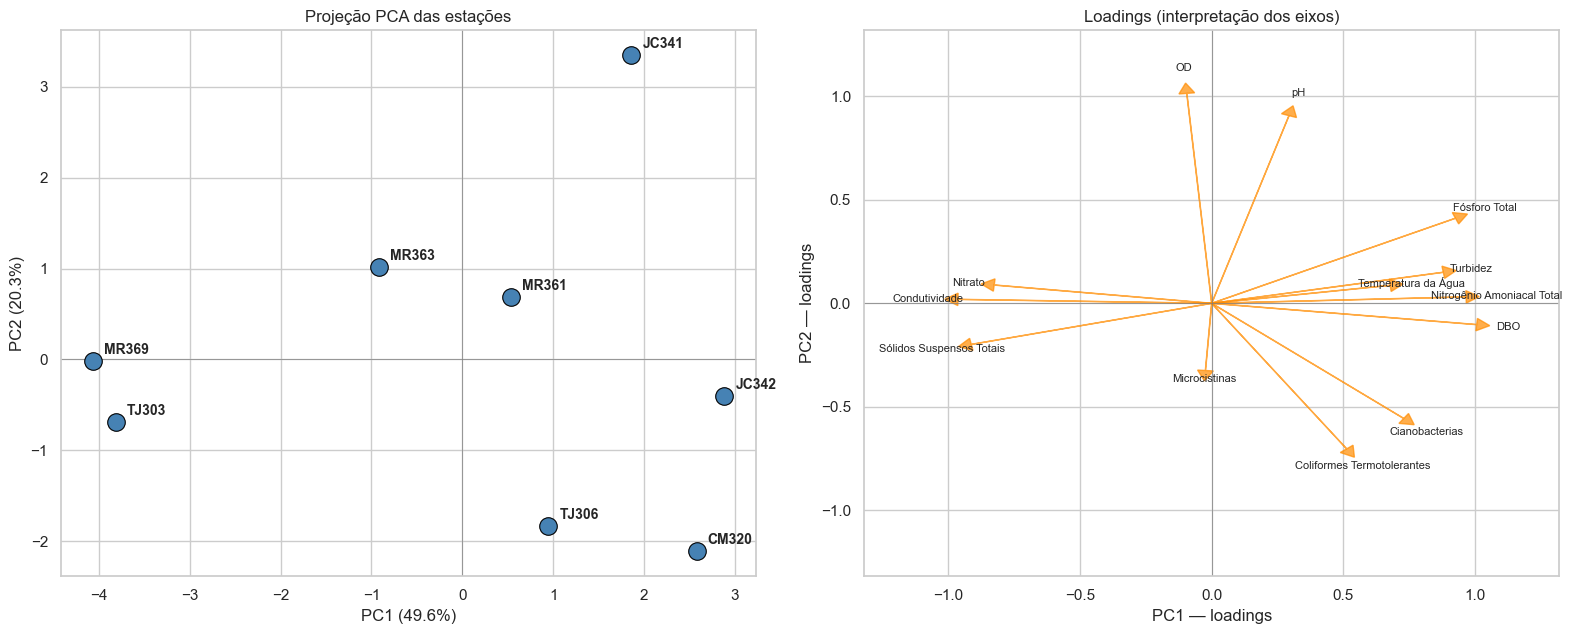


Loadings PC1 (positivo = mais eutrofizada):
Condutividade                -0.35
Sólidos Suspensos Totais     -0.34
Nitrato                      -0.30
OD                           -0.03
Microcistinas                -0.01
pH                            0.11
Coliformes Termotolerantes    0.19
Temperatura da Água           0.25
Cianobacterias                0.27
Turbidez                      0.32
Fósforo Total                 0.34
Nitrogênio Amoniacal Total    0.36
DBO                           0.37
Name: PC1, dtype: float64

Loadings PC2 (positivo = mais OD/pH):
Coliformes Termotolerantes   -0.40
Cianobacterias               -0.32
Microcistinas                -0.19
Sólidos Suspensos Totais     -0.11
DBO                          -0.06
Condutividade                 0.01
Nitrogênio Amoniacal Total    0.02
Nitrato                       0.05
Temperatura da Água           0.05
Turbidez                      0.09
Fósforo Total                 0.24
pH                            0.52
OD             

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Scatter PC1 x PC2
ax = axes[0]
ax.scatter(Y[:, 0], Y[:, 1], s=160, c="steelblue", edgecolor="black", linewidth=0.8, zorder=3)
for (x, y), st in zip(Y, STATIONS):
    ax.annotate(st, (x, y), xytext=(8, 5), textcoords="offset points",
                fontsize=10, fontweight="bold")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Projeção PCA das estações")

# Biplot de loadings
ax = axes[1]
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, v in enumerate(VARS):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.06,
             head_length=0.05, color="darkorange", alpha=0.7)
    ax.text(loadings[i, 0] * 1.12, loadings[i, 1] * 1.12, v, fontsize=8,
            ha="center", va="center")
lim = np.abs(loadings).max() * 1.3
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("PC1 — loadings")
ax.set_ylabel("PC2 — loadings")
ax.set_title("Loadings (interpretação dos eixos)")

plt.tight_layout()
fig.savefig(FIG_DIR / "est_pca.png", dpi=150)
plt.show()

# Loadings ordenados
load_df = pd.DataFrame(pca.components_.T, index=VARS, columns=["PC1", "PC2"]).round(2)
print("\nLoadings PC1 (positivo = mais eutrofizada):")
print(load_df["PC1"].sort_values())
print("\nLoadings PC2 (positivo = mais OD/pH):")
print(load_df["PC2"].sort_values())

**Como interpretar:**

- **PC1** (eixo horizontal) tipicamente captura o gradiente dominante; aqui é trofia/salinidade.
- **PC2** captura o segundo eixo ortogonal; aqui é fotossíntese/contaminação.
- Estações agrupadas no scatter = perfis semelhantes; isoladas = perfis únicos.
- Setas (loadings) longas = variável influente; setas alinhadas = variáveis redundantes.

**Achados específicos:**

- **PCA captura ~70% da variância em 2D** (PC1 = 49,6%, PC2 = 20,3%) — projeção informativa.
- **PC1 (gradiente trofia → salinidade):** loadings positivos altos em **DBO (+0,37), Nitrogênio Amoniacal (+0,36), Fósforo Total (+0,34), Turbidez (+0,32), Cianobactérias (+0,27)**; loadings negativos em **Condutividade (−0,35), Sólidos Suspensos (−0,34), Nitrato (−0,30)**.
- **PC2 (eixo fotossíntese × contaminação):** loadings positivos em **OD (+0,58) e pH (+0,52)**; negativos em **Coliformes (−0,40) e Cianobactérias (−0,32)**.
- **Posicionamento das estações:**
  - **MR369 (−4,07; ±0)** e **TJ303 (−3,81; −0,69):** extremo marinho/limpo. Cluster claro.
  - **CM320 (+2,58; −2,11):** extremo eutrofizado-contaminado (baixo OD/pH, alto Coliformes).
  - **JC342 (+2,89; −0,41):** eutrofizado mas menos contaminado.
  - **TJ306 (+0,95; −1,83):** intermediária, com tendência à contaminação (perto de CM320 em PC2).
  - **MR361 (+0,53; +0,69):** intermediário-positivo (parecido com estações limpas, mas menos extremo).
  - **JC341 (+1,86; +3,35)** e **MR363 (−0,92; +1,02):** **outliers** com alto PC2 — refletem amostras pequenas e ruidosas (n = 10 e 8), não estrutura real.

## 4. Clusterização hierárquica (Ward)

Ward minimiza a variância intra-cluster a cada fusão — produz dendrogramas interpretáveis e clusters compactos. O **corte vertical** sugere o número natural de clusters: um salto grande na altura significa que estamos fundindo grupos que estavam distantes (não pertencem juntos).

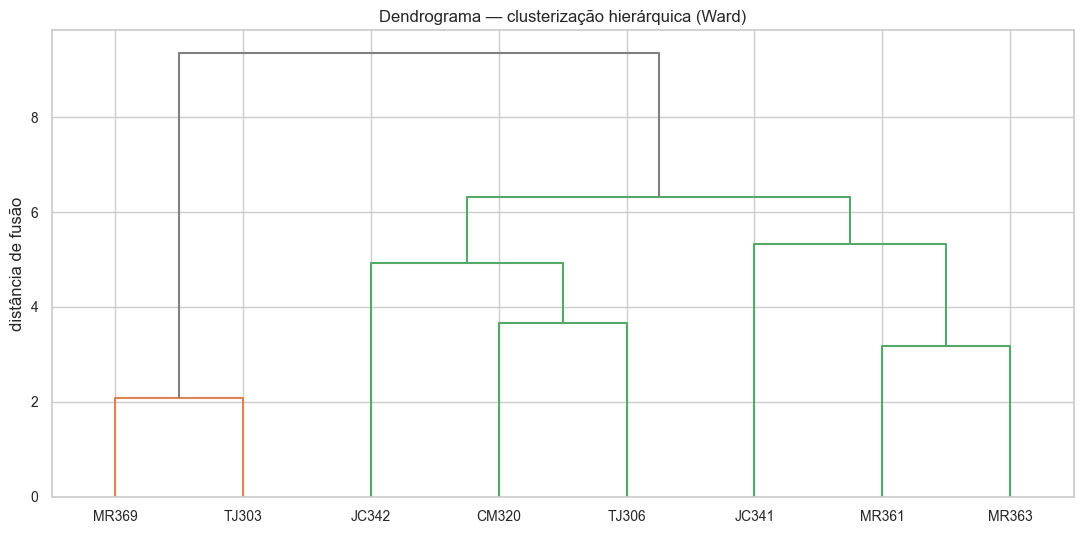

Distâncias das últimas 4 fusões (de baixo para cima):
[4.93 5.33 6.32 9.36]


In [9]:
Z = linkage(X_std, method="ward")

fig, ax = plt.subplots(figsize=(11, 5.5))
dendrogram(Z, labels=STATIONS, ax=ax, color_threshold=Z[-2, 2] + 0.01,
           above_threshold_color="gray")
ax.set_title("Dendrograma — clusterização hierárquica (Ward)")
ax.set_ylabel("distância de fusão")
ax.tick_params(labelsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / "est_dendrograma.png", dpi=150)
plt.show()

print("Distâncias das últimas 4 fusões (de baixo para cima):")
print(Z[-4:, 2].round(2))

**Como interpretar:**

- Cortar o dendrograma na altura `h` produz tantos clusters quantos forem os ramos cortados.
- O "melhor" corte está antes de um salto grande na altura.

**Achados específicos:**

- **Distâncias das últimas fusões:** 4,93 → 5,33 → 6,32 → **9,36**. O salto grande entre 6,32 e 9,36 indica que cortar **acima** dessa distância (K = 2) produz a estrutura mais natural.
- **K = 2:** {MR369, TJ303} vs {CM320, JC341, JC342, MR361, MR363, TJ306} — separação marinho-puro vs resto.
- **K = 3 (corte em 6,32):** adiciona {CM320, TJ306} como cluster intermediário, isolando JC341/JC342/MR361/MR363 como cluster de "eutrofizadas internas".
- Estrutura visual coerente com o PCA e com a hipótese de gradiente marinho→continental.

## 5. K-means — revisita do PIBIC

**Método do cotovelo** (inércia para K = 2..7) + **silhueta média** decidem K. A silhueta varia entre −1 e +1; valores acima de 0,3 indicam separação razoável.

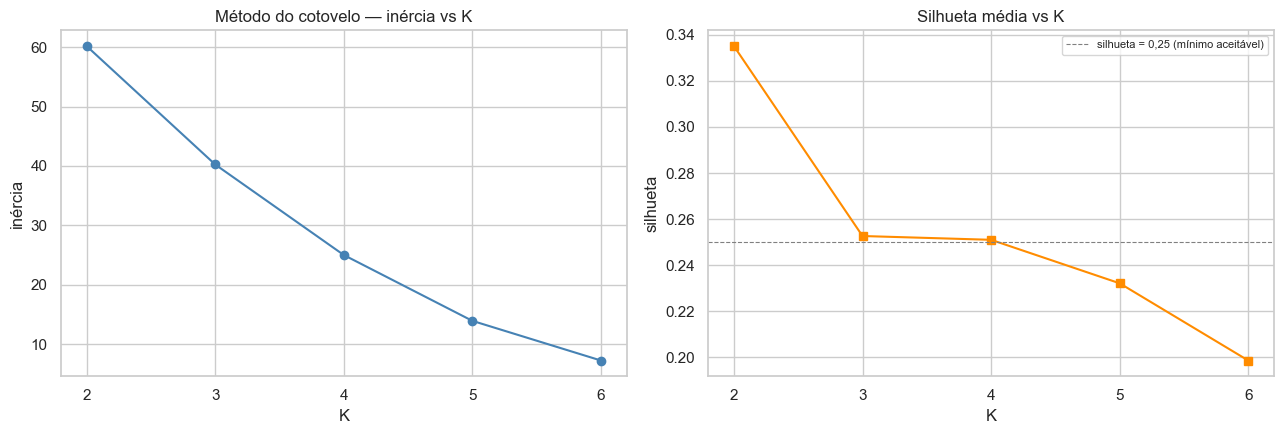

,inertia,silhueta
k,,
2,60.202,0.335
3,40.252,0.253
4,25.007,0.251
5,13.915,0.232
6,7.232,0.199


In [10]:
k_range = range(2, 7)
rows = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_std)
    sil = silhouette_score(X_std, km.labels_)
    rows.append({"k": k, "inertia": float(km.inertia_), "silhueta": float(sil),
                 "labels": km.labels_.tolist()})
tab_k = pd.DataFrame(rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(tab_k.index, tab_k["inertia"], marker="o", color="steelblue")
axes[0].set_title("Método do cotovelo — inércia vs K")
axes[0].set_xlabel("K"); axes[0].set_ylabel("inércia")
axes[0].set_xticks(list(k_range))

axes[1].plot(tab_k.index, tab_k["silhueta"], marker="s", color="darkorange")
axes[1].axhline(0.25, color="gray", ls="--", lw=0.8, label="silhueta = 0,25 (mínimo aceitável)")
axes[1].set_title("Silhueta média vs K")
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhueta")
axes[1].set_xticks(list(k_range))
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "est_kmeans_inercia.png", dpi=150)
plt.show()

tab_k[["inertia", "silhueta"]].round(3)

K escolhido pela silhueta: K = 2 (silhueta = 0.335)


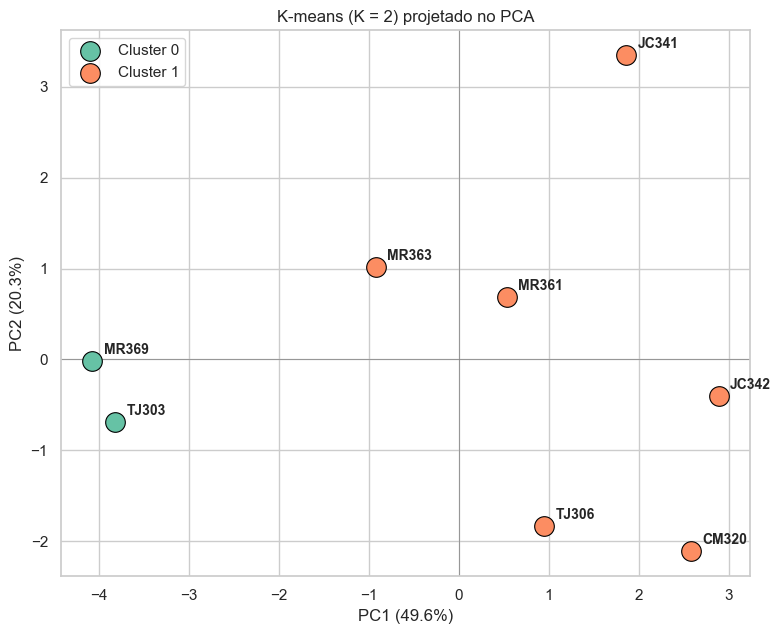

,estacao,cluster
0,JC341,1
1,JC342,1
2,CM320,1
3,MR361,1
4,MR363,1
5,MR369,0
6,TJ303,0
7,TJ306,1


In [11]:
# Escolha: K que maximiza silhueta
K_OPT = int(tab_k["silhueta"].idxmax())
print(f"K escolhido pela silhueta: K = {K_OPT} (silhueta = {tab_k.loc[K_OPT, 'silhueta']:.3f})")

km_final = KMeans(n_clusters=K_OPT, random_state=RANDOM_STATE, n_init=10).fit(X_std)
atrib = pd.DataFrame({"estacao": STATIONS, "cluster": km_final.labels_})
atrib.to_csv(TAB_DIR / "est_kmeans_atribuicao.csv", index=False)

# Plot sobre PCA
fig, ax = plt.subplots(figsize=(8, 6.5))
palette = sns.color_palette("Set2", K_OPT)
for c in range(K_OPT):
    mask = km_final.labels_ == c
    ax.scatter(Y[mask, 0], Y[mask, 1], s=200, color=palette[c],
               edgecolor="black", linewidth=0.8, label=f"Cluster {c}", zorder=3)
for (x, y), st in zip(Y, STATIONS):
    ax.annotate(st, (x, y), xytext=(8, 5), textcoords="offset points",
                fontsize=10, fontweight="bold")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"K-means (K = {K_OPT}) projetado no PCA")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIG_DIR / "est_kmeans_clusters.png", dpi=150)
plt.show()

atrib

**Como interpretar:**

- Cotovelo claro na inércia ≈ K natural.
- Silhueta cai monotonicamente em geral com poucas amostras (8); valor absoluto importa mais que o pico.
- K-means sobre PCA tem efeito visual mas o ajuste é feito no espaço padronizado original.

**Achados específicos:**

- **K = 2 vence pela silhueta** (0,335). Inércia também cai forte de K = 1 → 2 → 3 e suaviza depois.
- **Atribuição K = 2:** {MR369, TJ303} (marinhas) vs {CM320, JC341, JC342, MR361, MR363, TJ306} (continentais/eutrofizadas).
- **K = 3 (silhueta 0,254)** quebra o grupo continental em {CM320, TJ306} (mais contaminadas) vs {JC341, JC342, MR361, MR363} (eutrofizadas "limpas"). Estrutura interpretável mas com ganho marginal em silhueta.
- **Comparação com o PIBIC anterior (Dannylo 2023/2024):** o PIBIC usou K = 3 sobre 2012–2019. Aqui, com dados estendidos até 2025, **K = 2 é estatisticamente mais defensável**, mas K = 3 é interpretativamente atraente. A diferença reflete principalmente as observações pós-2020 — que reforçaram a separação marinha versus reduziram o contraste entre as estações continentais.

## Síntese final

### As estações são distintas?

**Sim, com forte evidência.** 8 das 13 variáveis rejeitam homogeneidade entre estações (Kruskal-Wallis p < 0,01). Os discriminadores espaciais mais fortes são **Condutividade, Turbidez, Fósforo Total, DBO e Coliformes Termotolerantes** — exatamente os indicadores que caracterizam o gradiente marinho→continental do sistema lagunar.

### Há clusters claros?

**Sim, K = 2 é a estrutura natural** (silhueta = 0,335, único valor positivo respeitável; salto grande no dendrograma entre as duas últimas fusões):

- **Cluster MARINHO:** MR369, TJ303 — alta Condutividade (~14k–34k), baixa DBO, baixa Turbidez, baixo Nitrogênio Amoniacal.
- **Cluster CONTINENTAL:** CM320, JC341, JC342, MR361, MR363, TJ306 — perfil eutrofizado/contaminado.

K = 3 (silhueta = 0,254) refina o cluster continental em "contaminadas" (CM320, TJ306) e "eutrofizadas" (JC341, JC342, MR361, MR363), mas com ganho marginal.

### Decisão para a GAIN: modelo único com `Codigo Local` como feature

**Trade-off explícito:**

| Estratégia | Prós | Contras |
|---|---|---|
| **1 GAIN com `Codigo Local` one-hot (escolhida)** | Treina com 657 amostras; gerador aprende todas as estações simultaneamente; feature condicional permite especialização implícita; mais robusto à esparsidade. | O gerador pode "misturar" distribuições; exige que a rede tenha capacidade suficiente para discriminar estações. |
| 2 GAINs (uma por cluster K=2) | Especialização explícita; cluster marinho tem ~228 amostras, continental ~429. | **Cluster marinho fica abaixo do mínimo viável** para treinar GAIN robusta; perde aprendizado cruzado entre clusters; duplica complexidade de avaliação. |
| 3 GAINs (uma por cluster K=3) | Especialização máxima. | **Inviável** — cada GAIN teria 113, 182 ou 362 amostras; sub-amostra demais para GAN. |

**Veredito:** manter a arquitetura planejada — **1 GAIN tabular única com `Codigo Local` como feature categórica codificada** (one-hot ou embedding). Os achados deste notebook validam que essa feature carrega informação espacial real e relevante.

### Cuidados específicos por estação

- **JC341 (n=10) e MR363 (n=8):** amostras insuficientes; posições instáveis no PCA. Recomendações: (a) considerar agrupá-las com as vizinhas geográficas (JC341 → JC342, MR363 → MR361) durante o treino, ou (b) mantê-las separadas mas com weight reduzido para não distorcer o gerador.
- **TJ306:** intermediária no PCA mas próxima de CM320 em PC2 (contaminação). Vale acompanhar se o gerador aprende a distinguir.

### Próximo notebook

`06_lds.ipynb` — caracteriza o padrão de censura (`_LD`) por variável e por estação, fechando a EDA antes do pré-processamento.